In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
orders = pd.read_csv('orders.csv')
customers=pd.read_csv('customers.csv')


In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [ ]:
orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

In [ ]:
orders.head()

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6


In [ ]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [ ]:
first_purchase = orders.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']

In [ ]:
orders = orders.merge(first_purchase, on='customer_unique_id')

In [ ]:
orders['month_offset'] = (orders['order_month'] - orders['cohort_month']).apply(lambda x: x.n)

In [ ]:
print(f"Total unique customers: {orders['customer_unique_id'].nunique()}")
print(f"Total orders (delivered): {len(orders)}")

Total unique customers: 96096
Total orders (delivered): 99441


In [ ]:
cohort_data = orders.groupby(['cohort_month', 'month_offset'])['customer_unique_id'].nunique().reset_index()

In [ ]:
cohort_table = cohort_data.pivot(index='cohort_month', columns='month_offset', values='customer_unique_id')

In [ ]:
cohort_sizes = cohort_table[0]
retention_table = cohort_table.divide(cohort_sizes, axis=0)

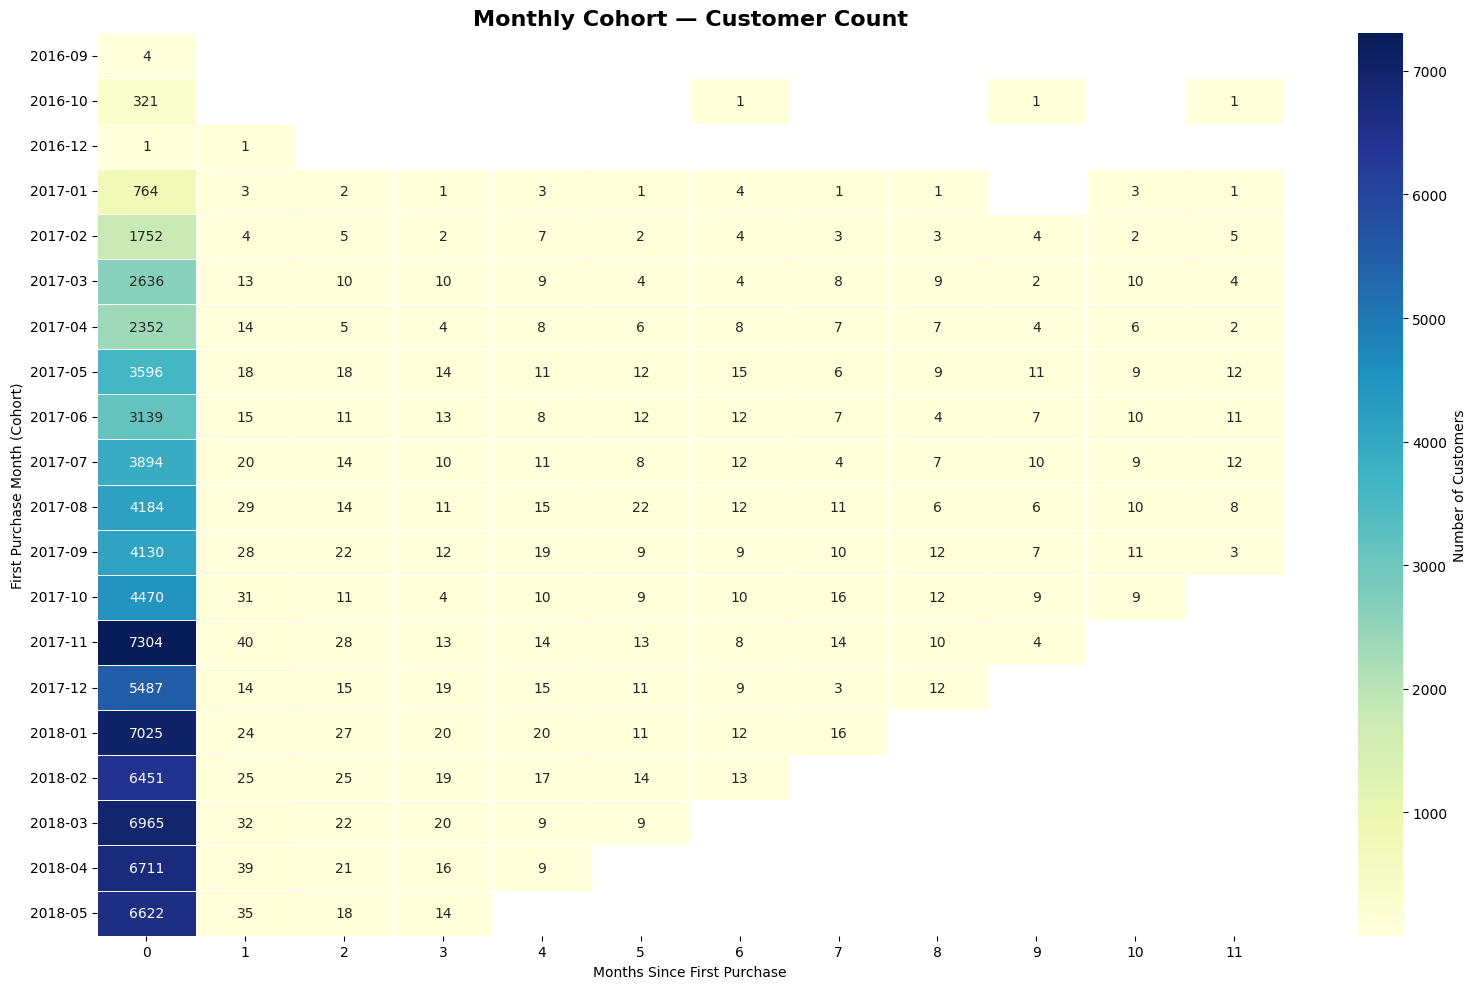

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(cohort_table.iloc[:20, :12], annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Number of Customers'})
plt.title('Monthly Cohort — Customer Count', fontsize=16, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('First Purchase Month (Cohort)')
plt.tight_layout()
plt.show()

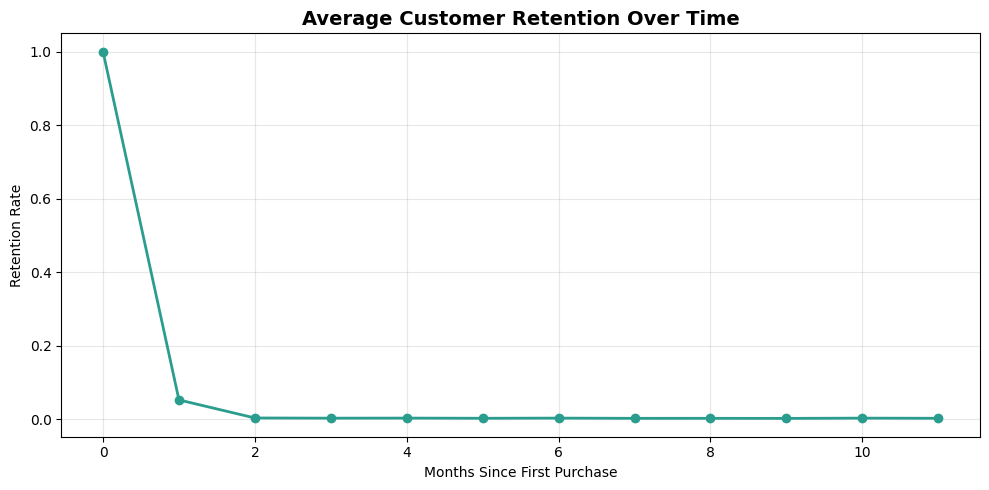

In [ ]:
first_12 = retention_table.iloc[:, :12]
avg_retention = first_12.mean()
plt.figure(figsize=(10, 5))
avg_retention.plot(marker='o', color='#2A9D8F', linewidth=2)
plt.title('Average Customer Retention Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total unique customers analyzed: {orders['customer_unique_id'].nunique()}")
print(f"Number of monthly cohorts: {len(cohort_sizes)}")
print(f"Average Month 1 retention: {retention_table[1].mean():.1%}")
print(f"Average Month 3 retention: {retention_table[3].mean():.1%}")
print(f"Average Month 6 retention: {retention_table[6].mean():.1%}")
print(f"Average Month 9 retention: {retention_table[9].mean():.1%}")
print(f"Average Month 12 retention: {retention_table[12].mean():.1%}")


Total unique customers analyzed: 96096
Number of monthly cohorts: 25
Average Month 1 retention: 5.2%
Average Month 3 retention: 0.3%
Average Month 6 retention: 0.3%
Average Month 9 retention: 0.2%
Average Month 12 retention: 0.2%
